# Получение золота из золотосодержащей руды

## Цель проекта

Подготовить прототип модели машинного обучения для предсказания коэффициента восстановления золота из золотосодержащей руды.

## Описание проекта

Подготовьте прототип модели машинного обучения для «Цифры». Компания разрабатывает решения для эффективной работы промышленных предприятий.
Модель должна предсказать коэффициент восстановления золота из золотосодержащей руды. В вашем распоряжении данные с параметрами добычи и очистки. 
Модель поможет оптимизировать производство, чтобы не запускать предприятие с убыточными характеристиками.

Вам нужно:
1. Подготовить данные;
2. Провести исследовательский анализ данных;
3. Построить и обучить модель.

## 1. Подготовка данных

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, fbeta_score, make_scorer
from sklearn.pipeline import  make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

### 1.1. Откроем файлы и изучим их

In [2]:
# чтение csv-файлов и сохранение их в переменные
try:
    df_full = pd.read_csv('/datasets/gold_recovery_full_new.csv')
    df_train = pd.read_csv('/datasets/gold_recovery_train_new.csv')
    df_test = pd.read_csv('/datasets/gold_recovery_test_new.csv')
except:
    df_full = pd.read_csv('C:/Users/evgen/Documents/data/Проекты по аналитике Яндекс/Данные для проектов/Золото/gold_recovery_full_new.csv')
    df_train = pd.read_csv('C:/Users/evgen/Documents/data/Проекты по аналитике Яндекс/Данные для проектов/Золото/gold_recovery_train_new.csv')
    df_test = pd.read_csv('C:/Users/evgen/Documents/data/Проекты по аналитике Яндекс/Данные для проектов/Золото/gold_recovery_test_new.csv')

In [3]:
# вывод на экран информации о файле с исходными данными
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                19439 non-null  object 
 1   final.output.concentrate_ag                         19438 non-null  float64
 2   final.output.concentrate_pb                         19438 non-null  float64
 3   final.output.concentrate_sol                        19228 non-null  float64
 4   final.output.concentrate_au                         19439 non-null  float64
 5   final.output.recovery                               19439 non-null  float64
 6   final.output.tail_ag                                19438 non-null  float64
 7   final.output.tail_pb                                19338 non-null  float64
 8   final.output.tail_sol                               19433 non-null  float64


In [4]:
# вывод на экран информации о файле с обучающей выборкой
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14149 entries, 0 to 14148
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                14149 non-null  object 
 1   final.output.concentrate_ag                         14148 non-null  float64
 2   final.output.concentrate_pb                         14148 non-null  float64
 3   final.output.concentrate_sol                        13938 non-null  float64
 4   final.output.concentrate_au                         14149 non-null  float64
 5   final.output.recovery                               14149 non-null  float64
 6   final.output.tail_ag                                14149 non-null  float64
 7   final.output.tail_pb                                14049 non-null  float64
 8   final.output.tail_sol                               14144 non-null  float64


In [5]:
# вывод на экран информации о файле с тестовой выборкой
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5290 entries, 0 to 5289
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5290 non-null   object 
 1   primary_cleaner.input.sulfate               5286 non-null   float64
 2   primary_cleaner.input.depressant            5285 non-null   float64
 3   primary_cleaner.input.feed_size             5290 non-null   float64
 4   primary_cleaner.input.xanthate              5286 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5290 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5290 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5290 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5290 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5290 non-null   float64
 10  primary_clea

В исходных данных 19 439 записей в 87 столбцах, есть пропуски в некоторых столбцах.

В обучающей выборке 14 149 записей в 87 столбцах, есть пропуски в данных.

В тестовой выборке 5 290 записей в 53 столбцах. Видимо в отсутствующих столбцах находятся целевые признаки и параметры которые замеряются и расчитваются позже.

### 1.2. Проверка правильности рассчета эффективности обогащения

Вычислим эффективность обогащения на обучающей выборке для признака rougher.output.recovery. Найдем МАЕ между полученными расчетами и значением признака.

In [6]:
#для облегчения расчетов зададим необходимые параметры
C = df_train['rougher.output.concentrate_au']
F = df_train['rougher.input.feed_au']
T = df_train['rougher.output.tail_au']

In [7]:
#создадим новый столбец для вычислений
df_train['recovery_calc'] = ((C*(F-T))/(F*(C-T)))*100
df_train['recovery_calc'].mean()

82.70450164550293

In [8]:
#сравним с прзнаком rougher.output.recovery
df_train['rougher.output.recovery'].mean()

82.70450164550293

In [9]:
# найдем МАЕ между полученными расчетами и значением признака
mae = mean_absolute_error(df_train['rougher.output.recovery'], df_train['recovery_calc'])
print("Средняя абсолютная ошибка:", mae)

Средняя абсолютная ошибка: 9.73512347450521e-15


In [10]:
#удалим проверочный столбец recovery_calc
df_train.drop('recovery_calc', axis= 1,inplace= True)

Значение МАЕ очень мало и близко к нулю, следовательно расчеты верны.

### 1.3. Анализ признаков, недоступных в тестовой выборке

In [11]:
# посмотрим какие признаки есть в исходных данных, но нет в тестовой выборке
set(df_full.columns) - set(df_test.columns)

{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.ta

В тестовой выборке отсутствуют столбцы с признаком параметра output - параметры продукта. А так же calculation - расчетные характеристики.

### 1.4. Предобработка данных

In [12]:
# проверим исходные данные на наличие явных дубликатов
df_full.duplicated().sum()

0

In [13]:
# проверим исходные данные на наличие неявных дубликатов
dup = df_full[df_full.duplicated(subset=['date', 
                                            'rougher.input.feed_ag',
                                           'rougher.input.feed_pb',
                                           'rougher.input.feed_rate',
                                           'rougher.input.feed_size',
                                           'rougher.input.feed_sol',
                                           'rougher.input.feed_au'])].shape[0]
print('Количество строк с дубликатами: ', dup)

Количество строк с дубликатами:  0


Дубликатов в исходных данных не обнаружено. Проверять тестовую и обучающую выборки не обязательно.

Посчитаем количество пропусков в каждом датасете

In [14]:
df_full.isnull().sum()

date                                            0
final.output.concentrate_ag                     1
final.output.concentrate_pb                     1
final.output.concentrate_sol                  211
final.output.concentrate_au                     0
                                             ... 
secondary_cleaner.state.floatbank5_a_level      1
secondary_cleaner.state.floatbank5_b_air        1
secondary_cleaner.state.floatbank5_b_level      1
secondary_cleaner.state.floatbank6_a_air        2
secondary_cleaner.state.floatbank6_a_level      1
Length: 87, dtype: int64

In [15]:
df_train.isnull().sum()

date                                            0
final.output.concentrate_ag                     1
final.output.concentrate_pb                     1
final.output.concentrate_sol                  211
final.output.concentrate_au                     0
                                             ... 
secondary_cleaner.state.floatbank5_a_level      1
secondary_cleaner.state.floatbank5_b_air        1
secondary_cleaner.state.floatbank5_b_level      1
secondary_cleaner.state.floatbank6_a_air        2
secondary_cleaner.state.floatbank6_a_level      1
Length: 87, dtype: int64

In [16]:
df_test.isnull().sum()

date                                           0
primary_cleaner.input.sulfate                  4
primary_cleaner.input.depressant               5
primary_cleaner.input.feed_size                0
primary_cleaner.input.xanthate                 4
primary_cleaner.state.floatbank8_a_air         0
primary_cleaner.state.floatbank8_a_level       0
primary_cleaner.state.floatbank8_b_air         0
primary_cleaner.state.floatbank8_b_level       0
primary_cleaner.state.floatbank8_c_air         0
primary_cleaner.state.floatbank8_c_level       0
primary_cleaner.state.floatbank8_d_air         0
primary_cleaner.state.floatbank8_d_level       0
rougher.input.feed_ag                          0
rougher.input.feed_pb                          0
rougher.input.feed_rate                        3
rougher.input.feed_size                        1
rougher.input.feed_sol                        21
rougher.input.feed_au                          0
rougher.input.floatbank10_sulfate              5
rougher.input.floatb

Пропусков довольно много. Нам известно, что данные индексируются датой и временем получения информации (признак date) и соседние по времени параметры часто похожи. Поэтому можем заполнить пропуски значением за предыдущий период времени.

In [17]:
df_full = df_full.fillna(method='ffill')
df_train = df_train.fillna(method='ffill')
df_test = df_test.fillna(method='ffill')

In [18]:
# проверим все ли пропуски заполнены
print('Пропусков в исходных данных:', sum(df_full.isnull().sum()))
print('Пропусков в обучающей выборке:', sum(df_train.isnull().sum()))
print('Пропусков в тестовой выборке:', sum(df_test.isnull().sum()))

Пропусков в исходных данных: 0
Пропусков в обучающей выборке: 0
Пропусков в тестовой выборке: 0


## 2. Анализ данных

### 2.1. Изучение изменения концентрации металлов на различных этапах очистки

In [19]:
#удаляем из датафрейма df_full концентрации меньше 1:
df_full = df_full[(df_full['rougher.input.feed_ag'] >= 1) &
            (df_full['rougher.input.feed_pb'] >= 1) &
            (df_full['rougher.input.feed_sol'] >= 1) &
            (df_full['rougher.input.feed_au'] >= 1) &
            (df_full['rougher.output.concentrate_ag'] >= 1) &
            (df_full['rougher.output.concentrate_pb'] >= 1) &
            (df_full['rougher.output.concentrate_sol'] >= 1) &
            (df_full['rougher.output.concentrate_au'] >= 1) &
            (df_full['primary_cleaner.output.concentrate_ag'] >= 1) &
            (df_full['primary_cleaner.output.concentrate_pb'] >= 1) &
            (df_full['primary_cleaner.output.concentrate_sol'] >= 1) &
            (df_full['primary_cleaner.output.concentrate_au'] >= 1) &
            (df_full['final.output.concentrate_ag'] >= 1) &
            (df_full['final.output.concentrate_pb'] >= 1) &
            (df_full['final.output.concentrate_sol'] >= 1) &
            (df_full['final.output.concentrate_au'] >= 1)]

In [20]:
#отфильтруем данные для каждого металла отдельно
df_ag = df_full[['rougher.input.feed_ag',
              'rougher.output.concentrate_ag', 
              'primary_cleaner.output.concentrate_ag', 
              'final.output.concentrate_ag']]
df_pb = df_full[['rougher.input.feed_pb',
              'rougher.output.concentrate_pb', 
              'primary_cleaner.output.concentrate_pb', 
              'final.output.concentrate_pb']]
df_au = df_full[['rougher.input.feed_au',
              'rougher.output.concentrate_au', 
              'primary_cleaner.output.concentrate_au', 
              'final.output.concentrate_au']]

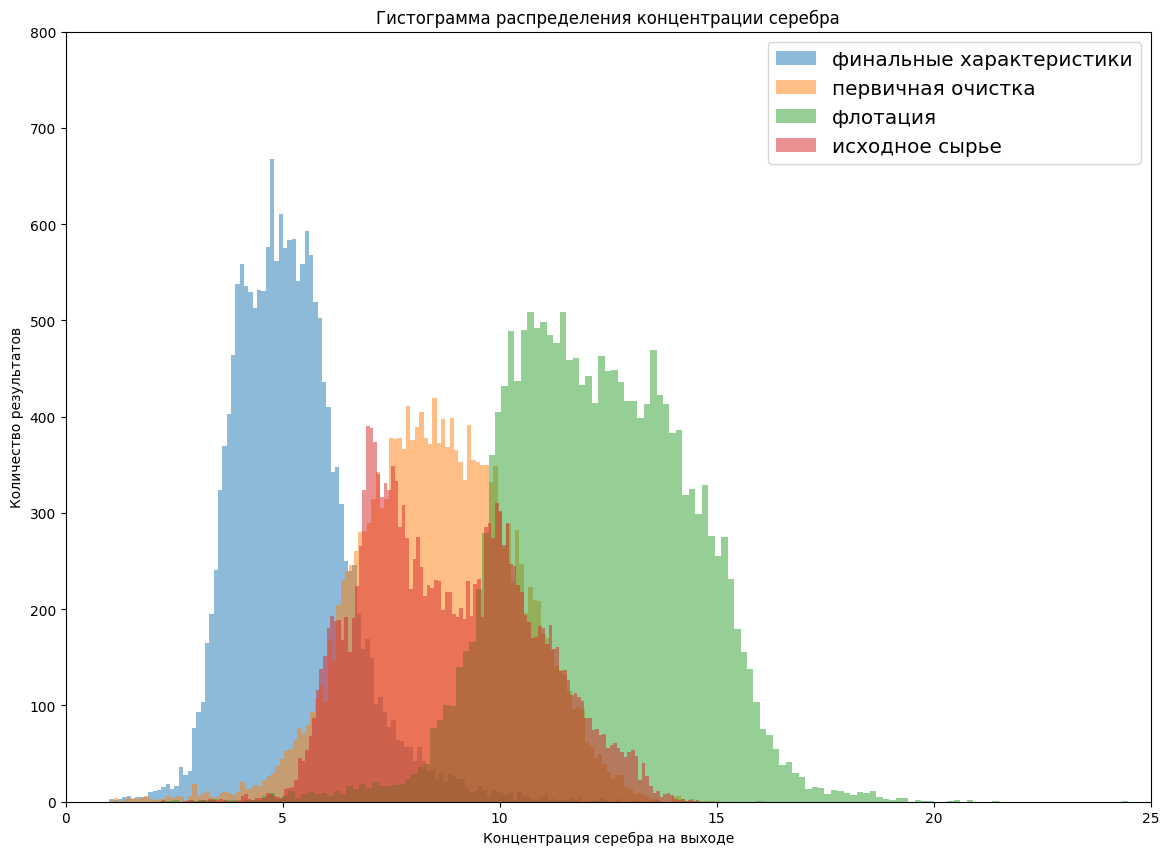

In [21]:
# концентрация серебра
plt.figure(figsize=[14,10])

plt.hist(df_ag['final.output.concentrate_ag'], bins=150, label = 'финальные характеристики', alpha=.5)
plt.hist(df_ag['primary_cleaner.output.concentrate_ag'], bins=150, label = 'первичная очистка', alpha=.5)
plt.hist(df_ag['rougher.output.concentrate_ag'], bins=150, label = 'флотация', alpha=.5)
plt.hist(df_ag['rougher.input.feed_ag'], bins=150, label = 'исходное сырье', alpha=.5)

plt.xlim([0, 25])
plt.ylim([0, 800])

plt.xlabel("Концентрация серебра на выходе")
plt.ylabel("Количество результатов")

plt.legend(loc='upper right', fontsize='x-large')

plt.title("Гистограмма распределения концентрации серебра")
plt.show()


Концентрация серебра увеличивается во время флотации по сравнению с исходным сырьем, но с каждым следующим этапом "пик" концентрации серебра смещается к нулю, что говорит о ее снижении.

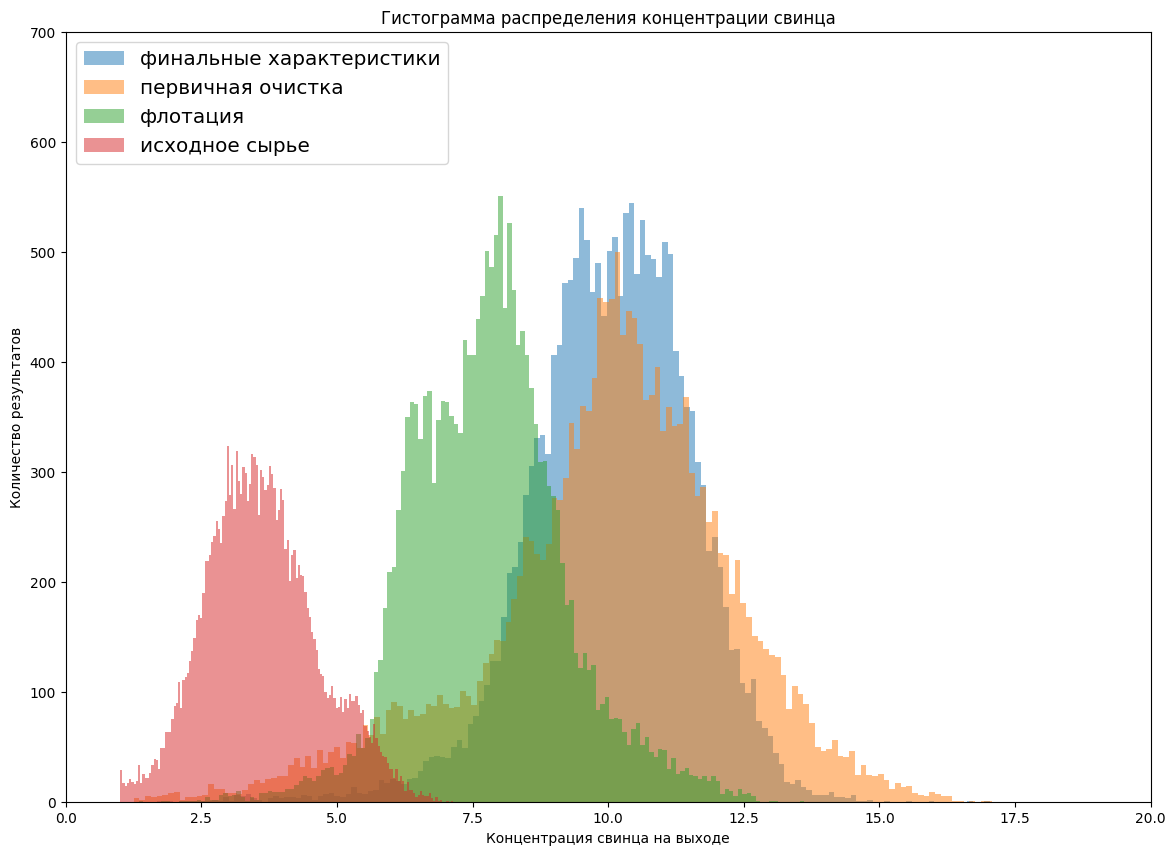

In [22]:
# концентрация свинца
plt.figure(figsize=[14,10])

plt.hist(df_pb['final.output.concentrate_pb'], bins=150, label = 'финальные характеристики', alpha=.5)
plt.hist(df_pb['primary_cleaner.output.concentrate_pb'], bins=150, label = 'первичная очистка', alpha=.5)
plt.hist(df_pb['rougher.output.concentrate_pb'], bins=150, label = 'флотация', alpha=.5)
plt.hist(df_pb['rougher.input.feed_pb'], bins=150, label = 'исходное сырье', alpha=.5)

plt.xlim([0, 20])
plt.ylim([0, 700])

plt.xlabel("Концентрация свинца на выходе")
plt.ylabel("Количество результатов")

plt.legend(loc='upper left', fontsize='x-large')

plt.title("Гистограмма распределения концентрации свинца")
plt.show()

В исходном сырье концентрация свинца не высока, увеличивается после флотации и первичной очистки. 

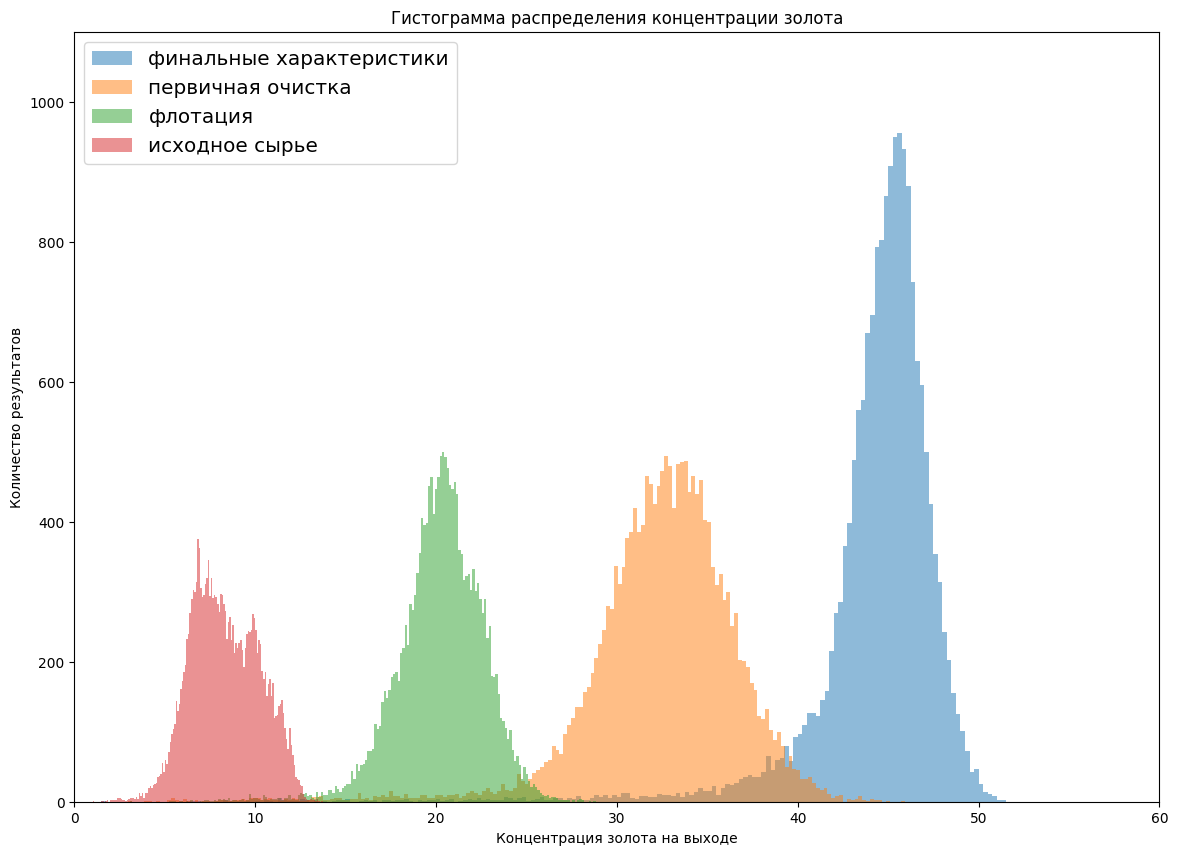

In [23]:
# концентрация золота
plt.figure(figsize=[14,10])

plt.hist(df_au['final.output.concentrate_au'], bins=200, label = 'финальные характеристики', alpha=.5)
plt.hist(df_au['primary_cleaner.output.concentrate_au'], bins=200, label = 'первичная очистка', alpha=.5)
plt.hist(df_au['rougher.output.concentrate_au'], bins=200, label = 'флотация', alpha=.5)
plt.hist(df_au['rougher.input.feed_au'], bins=150, label = 'исходное сырье', alpha=.5)

plt.xlim([0, 60])
plt.ylim([0, 1100])

plt.xlabel("Концентрация золота на выходе")
plt.ylabel("Количество результатов")

plt.legend(loc='upper left', fontsize='x-large')

plt.title("Гистограмма распределения концентрации золота")
plt.show()

Концентрация золота значительно повышается на каждом этапе обработки.

In [24]:
#так же удаляем из датафрейма df_train концентрации до 1:
df_train = df_train[(df_train['rougher.input.feed_ag'] >= 1) &
                    (df_train['rougher.input.feed_pb'] >= 1) &
                    (df_train['rougher.input.feed_sol'] >= 1) &
                    (df_train['rougher.input.feed_au'] >= 1) &
                    (df_train['rougher.output.concentrate_ag'] >= 1) &
                    (df_train['rougher.output.concentrate_pb'] >= 1) &
                    (df_train['rougher.output.concentrate_sol'] >= 1) &
                    (df_train['rougher.output.concentrate_au'] >= 1) &
                    (df_train['primary_cleaner.output.concentrate_ag'] >= 1) &
                    (df_train['primary_cleaner.output.concentrate_pb'] >= 1) &
                    (df_train['primary_cleaner.output.concentrate_sol'] >= 1) &
                    (df_train['primary_cleaner.output.concentrate_au'] >= 1) &
                    (df_train['final.output.concentrate_ag'] >= 1) &
                    (df_train['final.output.concentrate_pb'] >= 1) &
                    (df_train['final.output.concentrate_sol'] >= 1) &
                    (df_train['final.output.concentrate_au'] >= 1)]

In [25]:
#аналогично удаляем из датафрейма df_test концентрации до 1:
df_test = df_test[(df_test['rougher.input.feed_ag'] >= 1) &
                  (df_test['rougher.input.feed_pb'] >= 1) &
                  (df_test['rougher.input.feed_sol'] >= 1) &
                  (df_test['rougher.input.feed_au'] >= 1)]

### 2.2. Сравнение распределения размеров гранул сырья на обучающей и тестовой выборках

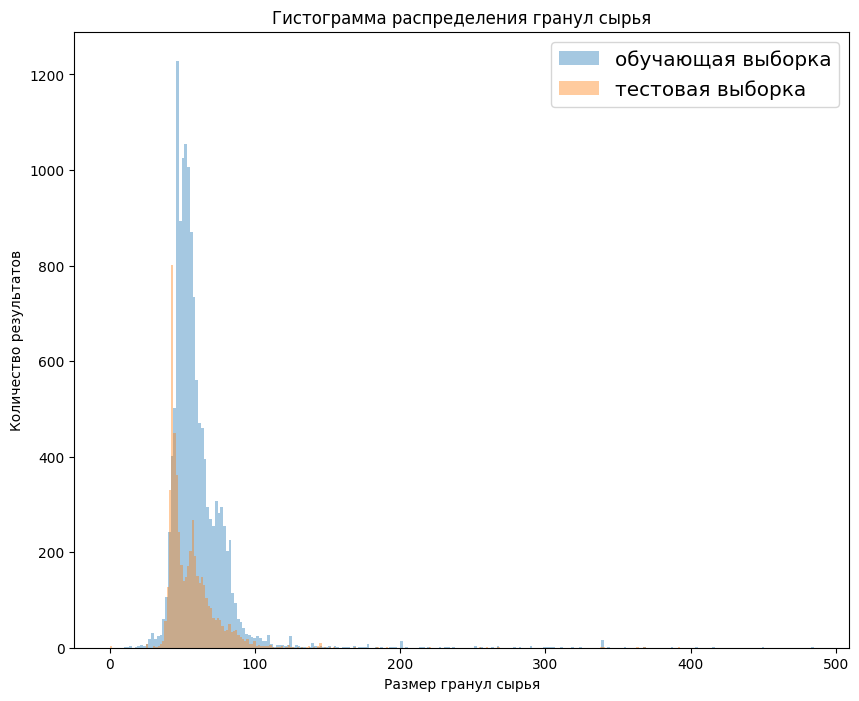

In [26]:
# первичный размер гранул сырья
plt.figure(figsize=[10,8])

plt.hist(df_train['rougher.input.feed_size'], bins=250, label = 'обучающая выборка', alpha=.4)
plt.hist(df_test['rougher.input.feed_size'], bins=250, label = 'тестовая выборка', alpha=.4)

plt.xlabel("Размер гранул сырья")
plt.ylabel("Количество результатов")

plt.legend(loc='upper right', fontsize='x-large')

plt.title("Гистограмма распределения гранул сырья")
plt.show()

Распределение размеров гранул в обоих выборках смещено влево, имеется много выбросов в размерах больше 150. В общем распределения размеров гранул не сильно отличаются. Проверим распределение размеров гранул после флотации.

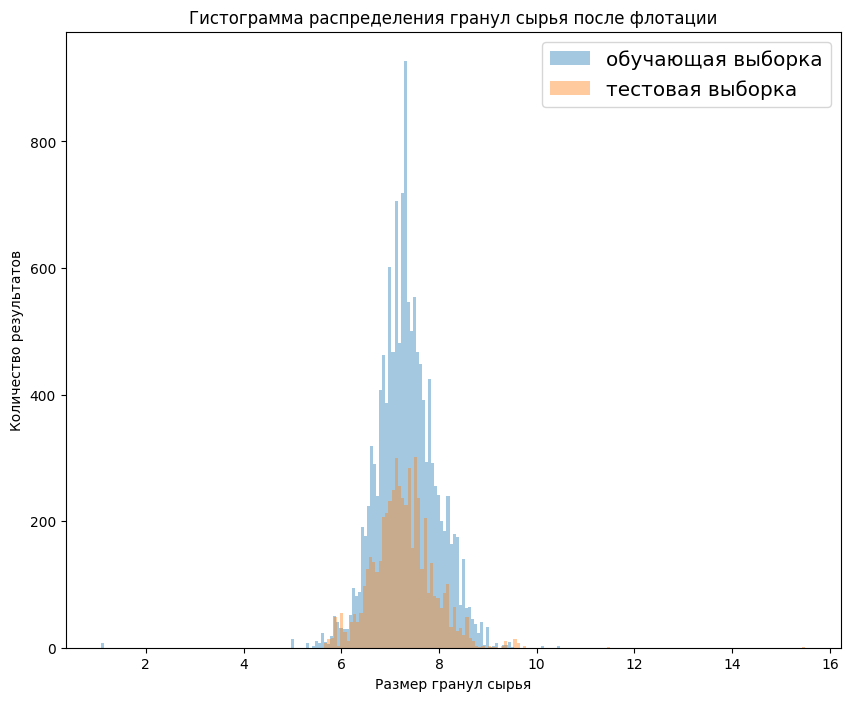

In [27]:
# размер гранул сырья после флотации
plt.figure(figsize=[10,8])

plt.hist(df_train['primary_cleaner.input.feed_size'], bins=150, label = 'обучающая выборка', alpha=.4)
plt.hist(df_test['primary_cleaner.input.feed_size'], bins=150, label = 'тестовая выборка', alpha=.4)

plt.xlabel("Размер гранул сырья")
plt.ylabel("Количество результатов")

plt.legend(loc='upper right', fontsize='x-large')

plt.title("Гистограмма распределения гранул сырья после флотации")
plt.show()

После флотации, перед первичной обработкой распределения размеров гранул в обоих выборках почти не отличаются.

### 2.3. Исследование суммарной концентрации всех веществ на разных стадиях

Добавим в обучающую выборку столбцы с суммой концентрации всех веществ на разных стадиях обработки.

In [28]:
# суммарная концентрация металлов в сырье
df_train['sum_concentrate_rougher_input'] = (df_train['rougher.input.feed_ag'] +
                                  df_train['rougher.input.feed_pb'] +
                                  df_train['rougher.input.feed_sol'] +
                                  df_train['rougher.input.feed_au'])

In [29]:
# суммарная концентрация металлов после флотации
df_train['sum_concentrate_rougher_output'] = (df_train['rougher.output.concentrate_ag'] +
                                  df_train['rougher.output.concentrate_pb'] +
                                  df_train['rougher.output.concentrate_sol'] +
                                  df_train['rougher.output.concentrate_au'])

In [30]:
# суммарная концентрация металлов после первичной обработки
df_train['sum_concentrate_primary_cleaner'] = (df_train['primary_cleaner.output.concentrate_ag'] +
                                  df_train['primary_cleaner.output.concentrate_pb'] +
                                  df_train['primary_cleaner.output.concentrate_sol'] +
                                  df_train['primary_cleaner.output.concentrate_au'])

In [31]:
# суммарная концентрация металлов после финальной обработки
df_train['sum_concentrate_final'] = (df_train['final.output.concentrate_ag'] +
                        df_train['final.output.concentrate_pb'] +
                        df_train['final.output.concentrate_sol'] +
                        df_train['final.output.concentrate_au'])

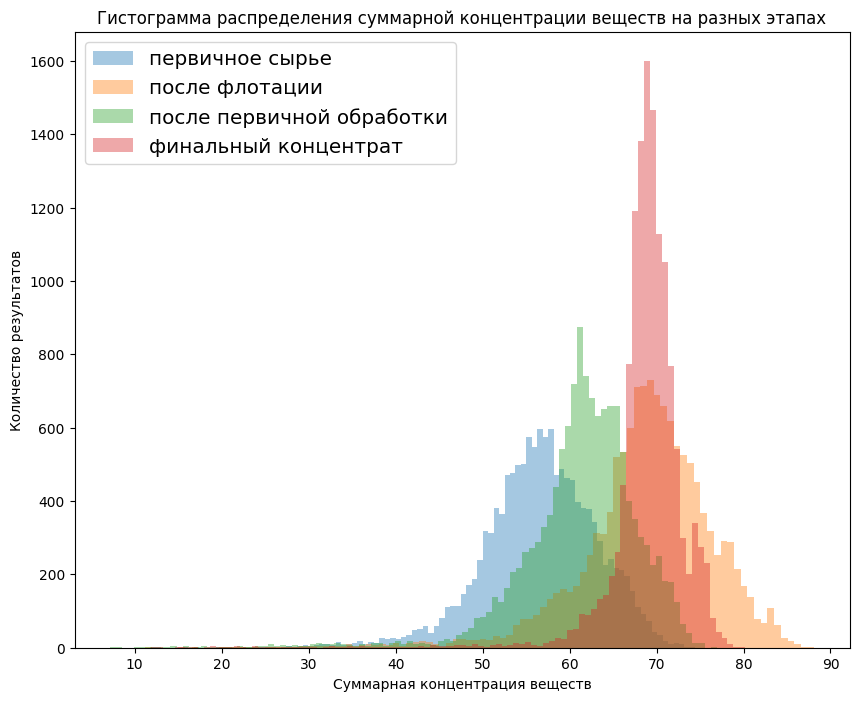

In [32]:
# построим гистограмму распределения суммарной концентрации веществ на разных этапах
plt.figure(figsize=[10,8])

plt.hist(df_train['sum_concentrate_rougher_input'], bins=100, label = 'первичное сырье', alpha=.4)
plt.hist(df_train['sum_concentrate_rougher_output'], bins=100, label = 'после флотации', alpha=.4)
plt.hist(df_train['sum_concentrate_primary_cleaner'], bins=100, label = 'после первичной обработки', alpha=.4)
plt.hist(df_train['sum_concentrate_final'], bins=100, label = 'финальный концентрат', alpha=.4)

plt.xlabel("Суммарная концентрация веществ")
plt.ylabel("Количество результатов")

plt.legend(loc='upper left', fontsize='x-large')

plt.title("Гистограмма распределения суммарной концентрации веществ на разных этапах")
plt.show()

Суммарная концентрация веществ возрастает от исходного сырья до конечного концентрата.

In [33]:
#df_train = df_train[df_train['sum_concentrate_rougher_input']>20]
#df_train = df_train[df_train['sum_concentrate_rougher_output']>20]
#df_train = df_train[df_train['sum_concentrate_primary_cleaner']>20]
#df_train = df_train[df_train['sum_concentrate_final']>20]

## 3. Построение модели

Подготовим признаки для final.output.recovery и rougher.output.recovery. Для этого удалим столбцы, которые не пригодятся в обучении модели

In [34]:
# удалим столбец data, так как не несет никакого смысла для обучения
features_col = df_test.columns[1:]
# для предсказания rougher.output.recovery используем данные из стобцов rougher
rougher_features_columns = set(features_col[12:34])
final_features_col = set(features_col)

In [35]:
# Подготовим признаки для final.output.recovery
columns_to_del = set(df_train.columns) - final_features_col
train_features_final = df_train.drop(columns_to_del, axis=1)
# print(train_features_final.columns)

# Подготовим признаки для rougher.output.recovery
columns_to_del = set(train_features_final.columns) - rougher_features_columns
train_features_rougher = train_features_final.drop(columns_to_del, axis=1)
# print(train_features_rougher.columns)

In [36]:
# Выделим целевые значения
target_values_rougher = df_train['rougher.output.recovery']
target_values_final = df_train['final.output.recovery']

### 3.1. Функция для вычисления итоговой sMAPE

In [37]:
def sMAPE(y_true,y_pred):
    err = np.mean(abs(y_true - y_pred)/((abs(y_true)+abs(y_pred))/2))*100
    return err

In [38]:
def final_sMAPE(sMAPE_rougher,sMAPE_final):
    return (0.25*sMAPE_rougher + 0.75*sMAPE_final)

### 3.2. Обучение моделей и оценка их качества

In [39]:
#вводим свою метрику через make_scorer
score = make_scorer(sMAPE, greater_is_better = False) 

In [40]:
#для оптимизации процесса обработки данных применяем make_pipeline для случайного леса и линейной регрессии:
model_RF = make_pipeline(StandardScaler(), RandomForestRegressor())
model_LR = make_pipeline(StandardScaler(), LinearRegression())

In [41]:
#задаем параметры для моделей:
parameters_RF = {'randomforestregressor__n_estimators':[3,200],
                  'randomforestregressor__max_depth':[1,10],
                  'randomforestregressor__random_state':[123]}
parameters_LR = {'linearregression__normalize':[False]}

#### Модели для прогноза эффективности обогащения чернового концентрата

In [42]:
grid_rougher_RF = GridSearchCV(model_RF, param_grid=parameters_RF, cv=5, scoring=score)
grid_rougher_LR = GridSearchCV(model_LR, param_grid=parameters_LR, scoring=score)

In [43]:
%%time
#обучаем модели:
grid_rougher_RF.fit(train_features_rougher, target_values_rougher)
grid_rougher_LR.fit(train_features_rougher, target_values_rougher)

CPU times: total: 4min 35s
Wall time: 4min 56s


GridSearchCV(estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('linearregression',
                                        LinearRegression())]),
             param_grid={'linearregression__normalize': [False]},
             scoring=make_scorer(sMAPE, greater_is_better=False))

In [44]:
#определяем лучшую из моделей 
best_score_rougher_RF = grid_rougher_RF.best_score_
best_score_rougher_LR = grid_rougher_LR.best_score_
print('по модели RandomForestRegressor лучший результат rougher =', best_score_rougher_RF)
print('по модели LinearRegression лучший результат rougher =', best_score_rougher_LR)

по модели RandomForestRegressor лучший результат rougher = -6.48660768503385
по модели LinearRegression лучший результат rougher = -6.666341627271585


Для прогноза эффективности обогащения чернового концентрата лучше подходит модель Случайный лес

#### Модели для прогноза эффективности обогащения финального концентрата

Теперь проверим какая модель больше подходит для прогноза эффективности обогащения финального концентрата

In [45]:
grid_final_RF = GridSearchCV(model_RF, param_grid=parameters_RF, cv=5, scoring=score)
grid_final_LR = GridSearchCV(model_LR, param_grid=parameters_LR, scoring=score)

In [46]:
%%time
#обучаем модели:
grid_final_RF.fit(train_features_final, target_values_final)
grid_final_LR.fit(train_features_final, target_values_final)

CPU times: total: 10min 34s
Wall time: 11min 42s


GridSearchCV(estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('linearregression',
                                        LinearRegression())]),
             param_grid={'linearregression__normalize': [False]},
             scoring=make_scorer(sMAPE, greater_is_better=False))

In [47]:
#определяем лучшую из моделей 
best_score_final_RF = grid_final_RF.best_score_
best_score_final_LR = grid_final_LR.best_score_

print('по модели RandomForestRegressor лучший результат final =', best_score_final_RF)
print('по модели LinearRegression лучший результат final =', best_score_final_LR)

по модели RandomForestRegressor лучший результат final = -9.034118886308587
по модели LinearRegression лучший результат final = -10.67650264506803


Для прогноза эффективности обогащения финального концентрата немного лучше результаты показала модель Случайный лес

Проверим итоговую оценку качества для обоих моделей

In [48]:
#вычисляем final sMAPE для каждой модели:
final_smape_RF = final_sMAPE(best_score_rougher_RF, best_score_final_RF)
print('Итоговая метрика для модели Случайный лес', final_smape_RF)

final_smape_LR = final_sMAPE(best_score_rougher_LR, best_score_final_LR)
print('Итоговая метрика для модели Линейная регрессия', final_smape_LR)

Итоговая метрика для модели Случайный лес -8.397241085989902
Итоговая метрика для модели Линейная регрессия -9.67396239061892


Случайный лес показал лучшие метрики качества, но скорость обработки у нее выше. Проверку на тестовой выборке проведем на нем.

#### Проверка модели на тестовой выборке

In [49]:
#добавим в тестовую выборку целевые признаки из исходных данных по совпадению даты:
df_for_test = df_full[['date', 'rougher.output.recovery', 'final.output.recovery']]
df_test = df_test.merge(df_for_test, on='date')
df_test.shape

(5083, 55)

In [50]:
#df_test.info()

In [51]:
# Подготовим признаки для final.output.recovery
columns_to_del = set(df_test.columns) - final_features_col
test_features_final = df_test.drop(columns_to_del, axis=1)

# Подготовим признаки для rougher.output.recovery
columns_to_del = set(test_features_final.columns) - rougher_features_columns
test_features_rougher = test_features_final.drop(columns_to_del, axis=1)

# Выделим целевые значения
test_target_values_rougher = df_test['rougher.output.recovery']
test_target_values_final = df_test['final.output.recovery']

In [52]:
pred_test_predict = grid_rougher_RF.predict(test_features_rougher)
mae = mean_absolute_error(test_target_values_rougher, pred_test_predict)
smape_rougher = sMAPE(test_target_values_rougher, pred_test_predict)
print("MAE:", mae)
print("SMAPE:", smape_rougher)

MAE: 3.6619033813153155
SMAPE: 4.349996498063604


In [53]:
pred_test_final = grid_final_RF.predict(test_features_final)
mae = mean_absolute_error(test_target_values_final, pred_test_final)
smape_final = sMAPE(test_target_values_final, pred_test_final)
print("MAE:", mae)
print("SMAPE:", smape_final)

MAE: 5.432417686589841
SMAPE: 8.115241621543205


In [54]:
#
print('Итоговая метрика для модели Случайный лес =', final_sMAPE(smape_rougher, smape_final))

Итоговая метрика для модели Случайный лес = 7.173930340673305


#### Проверка модели на адекватность

In [55]:
dummy_regressor_rougher = DummyRegressor(strategy="mean")
dummy_regressor_rougher.fit(train_features_rougher,target_values_rougher)
dummy_rougher_pred = dummy_regressor_rougher.predict(test_features_rougher)
smape_dummy_rougher = sMAPE(test_target_values_rougher, dummy_rougher_pred)
print(smape_dummy_rougher) 

5.136402835889583


In [56]:
dummy_regressor_final = DummyRegressor(strategy="mean")
dummy_regressor_final.fit(train_features_final,target_values_final)
dummy_final_pred = dummy_regressor_final.predict(test_features_final)
smape_dummy_final = sMAPE(test_target_values_final, dummy_final_pred)
print(smape_dummy_final) 

8.373900455350764


In [57]:
print('Итоговая метрика', final_sMAPE(smape_dummy_rougher, smape_dummy_final))

Итоговая метрика 7.564526050485469


Итоговая метрика качества модели для константной модели - 7.56, это немного выше чем для модели Случайный лес - 7.17. Поэтому будем считать, что наша модель прошла проверку на адекватность

### Выводы

В рамках проекта исследовали процесс очистки золотоносной руды.
Задача состояла в подготовке прототипа модели машинного обучения для предсказания коэффициента восстановления золота из золотосодержащей руды.

Проведена предобрабока данных и исследованы признаки. Проанализировали данные, в частности изменение концентрации металлов на различных этапах очистки, распределение размеров гранул сырья и суммарная концентрация всех веществ.
Обучены по 2 модели для каждого этапа: линейная регрессия и случайный лес. В качестве итоговой модели был выбран случайный лес для обоих этапов очистки.
Итоговая метрика для модели Случайный лес на тестовой выборке составила 7.17